<a href="https://colab.research.google.com/github/elangbijak4/multi-agent-AI/blob/main/Optimasi2_Model_Perceptron_pada_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 000 | Loss: 43.2906 | Brain(w=1.105, b=-1.047)
Step 025 | Loss: 2.6710 | Brain(w=2.526, b=-0.250)
Step 050 | Loss: 2.4805 | Brain(w=2.526, b=0.037)
Step 075 | Loss: 2.4558 | Brain(w=2.526, b=0.141)
Step 100 | Loss: 2.4526 | Brain(w=2.526, b=0.178)
Step 125 | Loss: 2.4521 | Brain(w=2.526, b=0.191)


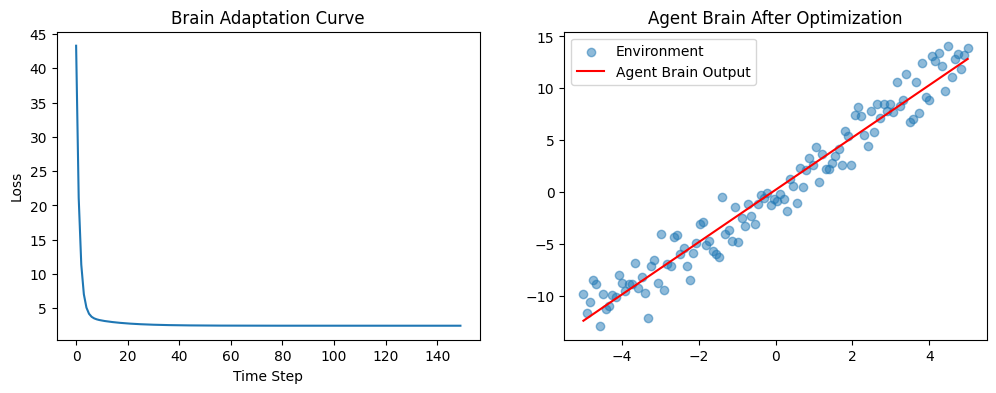

In [3]:
# ============================================================
# AGENT WITH EXPLICIT BRAIN MODEL
# Brain Optimization as Intelligent Adaptation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. ENVIRONMENT (WORLD)
# ------------------------------------------------------------
# World law (unknown to agent): y = 2.5x + noise
np.random.seed(0)
X = np.linspace(-5, 5, 120)
y = 2.5 * X + np.random.normal(0, 1.5, size=len(X))

# ------------------------------------------------------------
# 2. BRAIN DEFINITION
# ------------------------------------------------------------
class LinearBrain:
    """
    This class represents the AGENT'S BRAIN.
    Internal state = parameters (w, b)
    """
    def __init__(self):
        self.w = np.random.randn()
        self.b = np.random.randn()

    def forward(self, x):
        return self.w * x + self.b


# ------------------------------------------------------------
# 3. AGENT DEFINITION
# ------------------------------------------------------------
class IntelligentAgent:
    """
    Agent = Brain + Rational Adaptation Mechanism
    """
    def __init__(self, brain, learning_rate=0.01):
        self.brain = brain
        self.lr = learning_rate
        self.loss_history = []

    def perceive(self, X):
        return self.brain.forward(X)

    def evaluate(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def adapt_brain(self, X, y_true):
        """
        Brain optimization = internal cognitive adaptation
        """
        y_pred = self.perceive(X)

        # Gradients (local causal feedback)
        dw = 2 * np.mean((y_pred - y_true) * X)
        db = 2 * np.mean(y_pred - y_true)

        # Modify brain structure
        self.brain.w -= self.lr * dw
        self.brain.b -= self.lr * db

    def live(self, X, y, epochs=150):
        for t in range(epochs):
            y_pred = self.perceive(X)
            loss = self.evaluate(y_pred, y)
            self.loss_history.append(loss)

            self.adapt_brain(X, y)

            if t % 25 == 0:
                print(
                    f"Step {t:03d} | "
                    f"Loss: {loss:.4f} | "
                    f"Brain(w={self.brain.w:.3f}, b={self.brain.b:.3f})"
                )


# ------------------------------------------------------------
# 4. SIMULATION
# ------------------------------------------------------------
brain = LinearBrain()
agent = IntelligentAgent(brain, learning_rate=0.02)
agent.live(X, y)

# ------------------------------------------------------------
# 5. VISUALIZATION
# ------------------------------------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(agent.loss_history)
plt.xlabel("Time Step")
plt.ylabel("Loss")
plt.title("Brain Adaptation Curve")

plt.subplot(1,2,2)
plt.scatter(X, y, alpha=0.5, label="Environment")
plt.plot(X, agent.perceive(X), color='red', label="Agent Brain Output")
plt.legend()
plt.title("Agent Brain After Optimization")

plt.show()